# Task 2

---

## Predictive modeling of customer bookings

This Jupyter notebook includes some code to get you started with this predictive modeling task. We will use various packages for data manipulation, feature engineering and machine learning.

### Exploratory data analysis

First, we must explore the data in order to better understand what we have and the statistical properties of the dataset.

In [1]:
import pandas as pd

In [ ]:
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")
df.head(10)

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0
5,1,Internet,RoundTrip,3,48,20,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
6,3,Internet,RoundTrip,201,33,6,Thu,AKLDEL,New Zealand,1,0,1,5.52,0
7,2,Internet,RoundTrip,238,19,14,Mon,AKLDEL,India,1,0,1,5.52,0
8,1,Internet,RoundTrip,80,22,4,Mon,AKLDEL,New Zealand,0,0,1,5.52,0
9,1,Mobile,RoundTrip,378,30,12,Sun,AKLDEL,India,0,0,0,5.52,0


The `.head()` method allows us to view the first 5 rows in the dataset, this is useful for visual inspection of our columns

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

The `.info()` method gives us a data description, telling us the names of the columns, their data types and how many null values we have. Fortunately, we have no null values. It looks like some of these columns should be converted into different data types, e.g. flight_day.

To provide more context, below is a more detailed data description, explaining exactly what each column means:

- `num_passengers` = number of passengers travelling
- `sales_channel` = sales channel booking was made on
- `trip_type` = trip Type (Round Trip, One Way, Circle Trip)
- `purchase_lead` = number of days between travel date and booking date
- `length_of_stay` = number of days spent at destination
- `flight_hour` = hour of flight departure
- `flight_day` = day of week of flight departure
- `route` = origin -> destination flight route
- `booking_origin` = country from where booking was made
- `wants_extra_baggage` = if the customer wanted extra baggage in the booking
- `wants_preferred_seat` = if the customer wanted a preferred seat in the booking
- `wants_in_flight_meals` = if the customer wanted in-flight meals in the booking
- `flight_duration` = total duration of flight (in hours)
- `booking_complete` = flag indicating if the customer completed the booking

Before we compute any statistics on the data, lets do any necessary data conversion

In [4]:
df["flight_day"].unique()

array(['Sat', 'Wed', 'Thu', 'Mon', 'Sun', 'Tue', 'Fri'], dtype=object)

In [5]:
mapping = {
    "Mon": 1,
    "Tue": 2,
    "Wed": 3,
    "Thu": 4,
    "Fri": 5,
    "Sat": 6,
    "Sun": 7,
}

df["flight_day"] = df["flight_day"].map(mapping)

In [6]:
df["flight_day"].unique()

array([6, 3, 4, 1, 7, 2, 5])

In [7]:
df.describe()

,num_passengers,purchase_lead,length_of_stay,flight_hour,flight_day,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
count,50000.000000,50000.000000,50000.00000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,1.591240,84.940480,23.04456,9.06634,3.814420,0.668780,0.296960,0.427140,7.277561,0.149560
std,1.020165,90.451378,33.88767,5.41266,1.992792,0.470657,0.456923,0.494668,1.496863,0.356643
min,1.000000,0.000000,0.00000,0.00000,1.000000,0.000000,0.000000,0.000000,4.670000,0.000000
25%,1.000000,21.000000,5.00000,5.00000,2.000000,0.000000,0.000000,0.000000,5.620000,0.000000
50%,1.000000,51.000000,17.00000,9.00000,4.000000,1.000000,0.000000,0.000000,7.570000,0.000000
75%,2.000000,115.000000,28.00000,13.00000,5.000000,1.000000,1.000000,1.000000,8.830000,0.000000
max,9.000000,867.000000,778.00000,23.00000,7.000000,1.000000,1.000000,1.000000,9.500000,1.000000


The `.describe()` method gives us a summary of descriptive statistics over the entire dataset (only works for numeric columns). This gives us a quick overview of a few things such as the mean, min, max and overall distribution of each column.

From this point, you should continue exploring the dataset with some visualisations and other metrics that you think may be useful. Then, you should prepare your dataset for predictive modelling. Finally, you should train your machine learning model, evaluate it with performance metrics and output visualisations for the contributing variables. All of this analysis should be summarised in your single slide.

# EDA

C:\Users\User\AppData\Local\Temp\ipykernel_15964\518219490.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='booking_complete', data=df, palette='Set2')


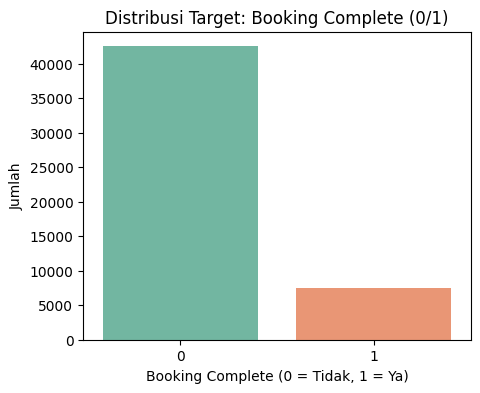

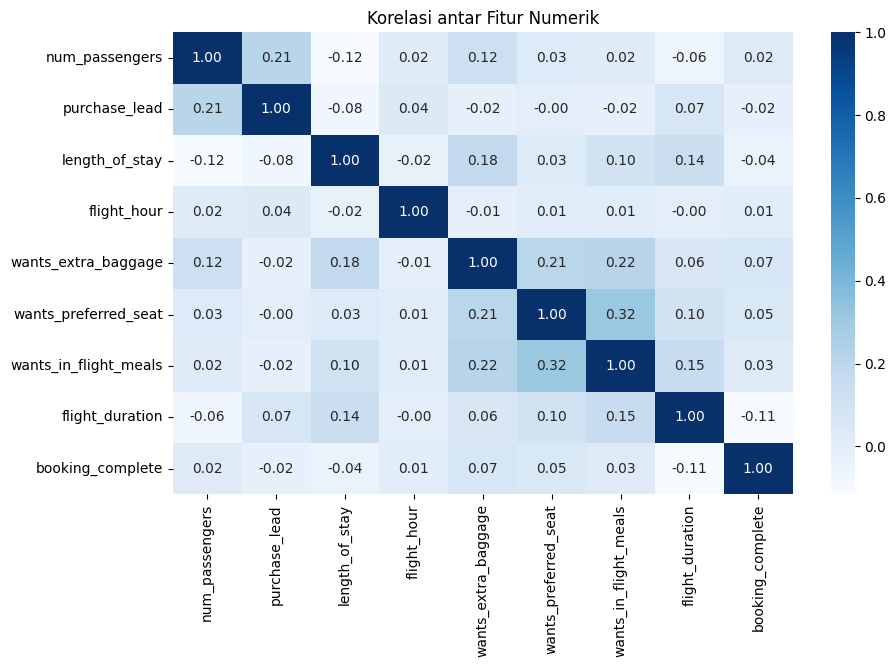

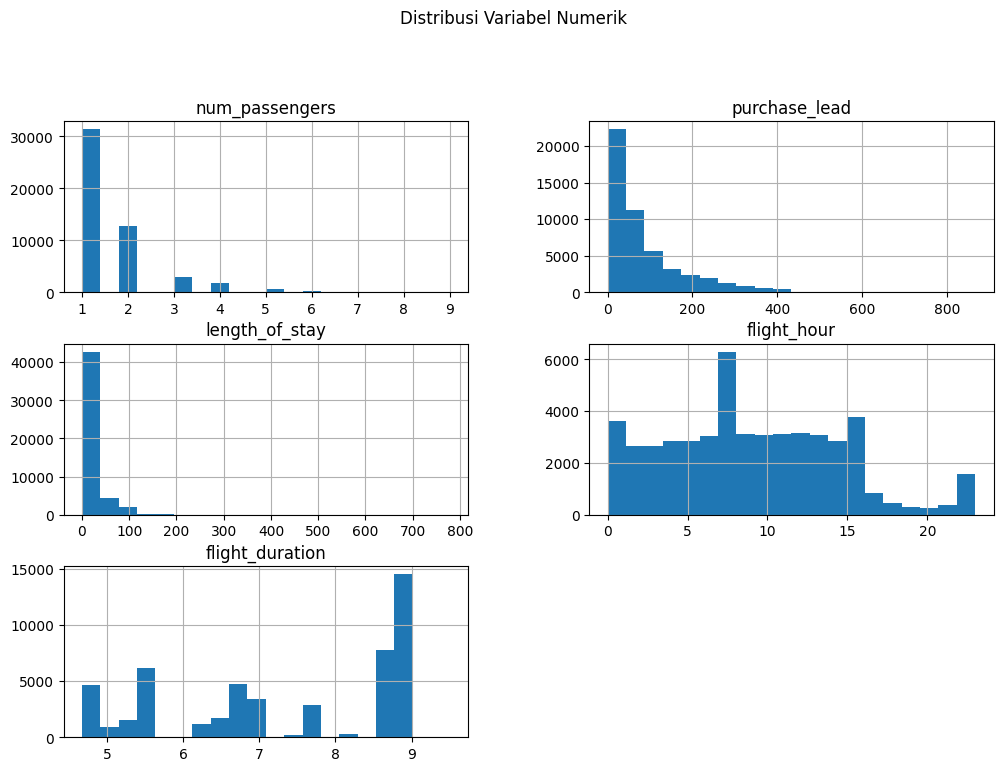

C:\Users\User\AppData\Local\Temp\ipykernel_15964\518219490.py:30: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='sales_channel', y='booking_complete', data=df, ci=None, palette='viridis')
C:\Users\User\AppData\Local\Temp\ipykernel_15964\518219490.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='sales_channel', y='booking_complete', data=df, ci=None, palette='viridis')


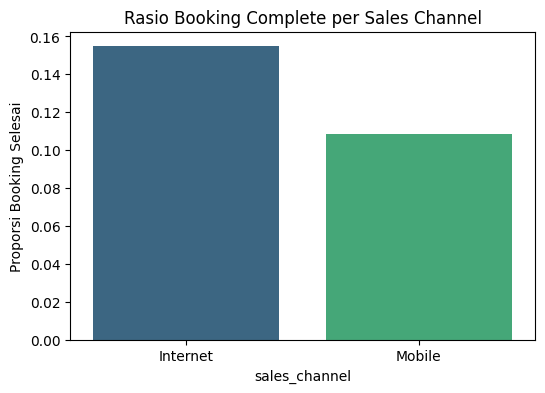

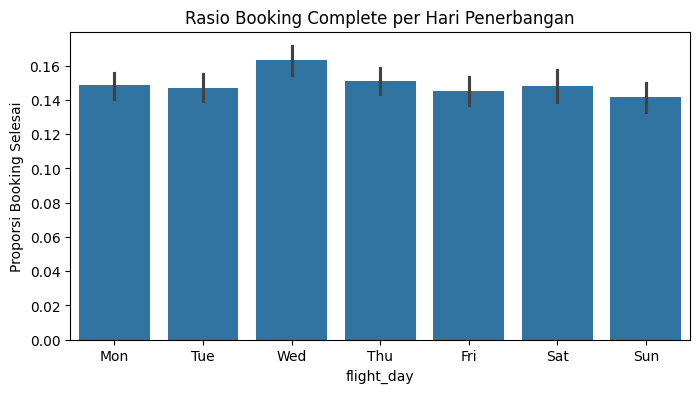

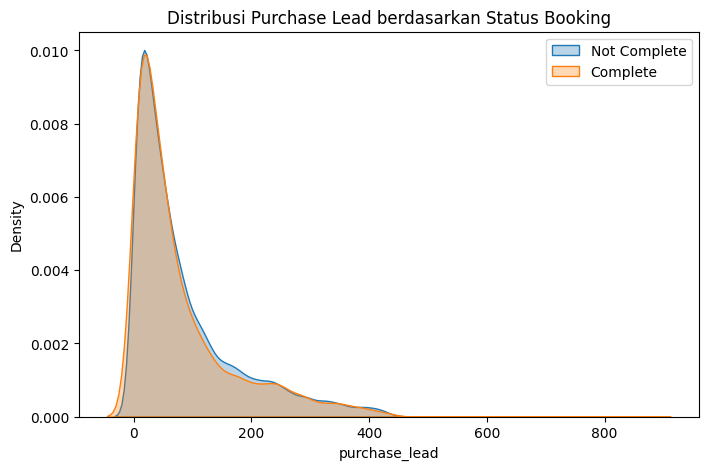

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === Load dataset ===
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")

# === Distribusi target ===
plt.figure(figsize=(5,4))
sns.countplot(x='booking_complete', data=df, palette='Set2')
plt.title("Distribusi Target: Booking Complete (0/1)")
plt.xlabel("Booking Complete (0 = Tidak, 1 = Ya)")
plt.ylabel("Jumlah")
plt.show()

# === Korelasi antar variabel numerik ===
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='Blues', fmt=".2f")
plt.title("Korelasi antar Fitur Numerik")
plt.show()

# === Distribusi kolom utama ===
numeric_cols = ['num_passengers','purchase_lead','length_of_stay','flight_hour','flight_duration']
df[numeric_cols].hist(bins=20, figsize=(12,8))
plt.suptitle("Distribusi Variabel Numerik", y=1.02)
plt.show()

# === Booking Complete berdasarkan Sales Channel ===
plt.figure(figsize=(6,4))
sns.barplot(x='sales_channel', y='booking_complete', data=df, ci=None, palette='viridis')
plt.title("Rasio Booking Complete per Sales Channel")
plt.ylabel("Proporsi Booking Selesai")
plt.show()

# === Booking Complete berdasarkan Hari Penerbangan ===
plt.figure(figsize=(8,4))
sns.barplot(x='flight_day', y='booking_complete', data=df, order=['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
plt.title("Rasio Booking Complete per Hari Penerbangan")
plt.ylabel("Proporsi Booking Selesai")
plt.show()

# === Hubungan antara Purchase Lead dan Booking Complete ===
plt.figure(figsize=(8,5))
sns.kdeplot(x='purchase_lead', data=df[df['booking_complete']==0], label='Not Complete', fill=True, alpha=0.3)
sns.kdeplot(x='purchase_lead', data=df[df['booking_complete']==1], label='Complete', fill=True, alpha=0.3)
plt.legend()
plt.title("Distribusi Purchase Lead berdasarkan Status Booking")
plt.show()


# Feature Engineering

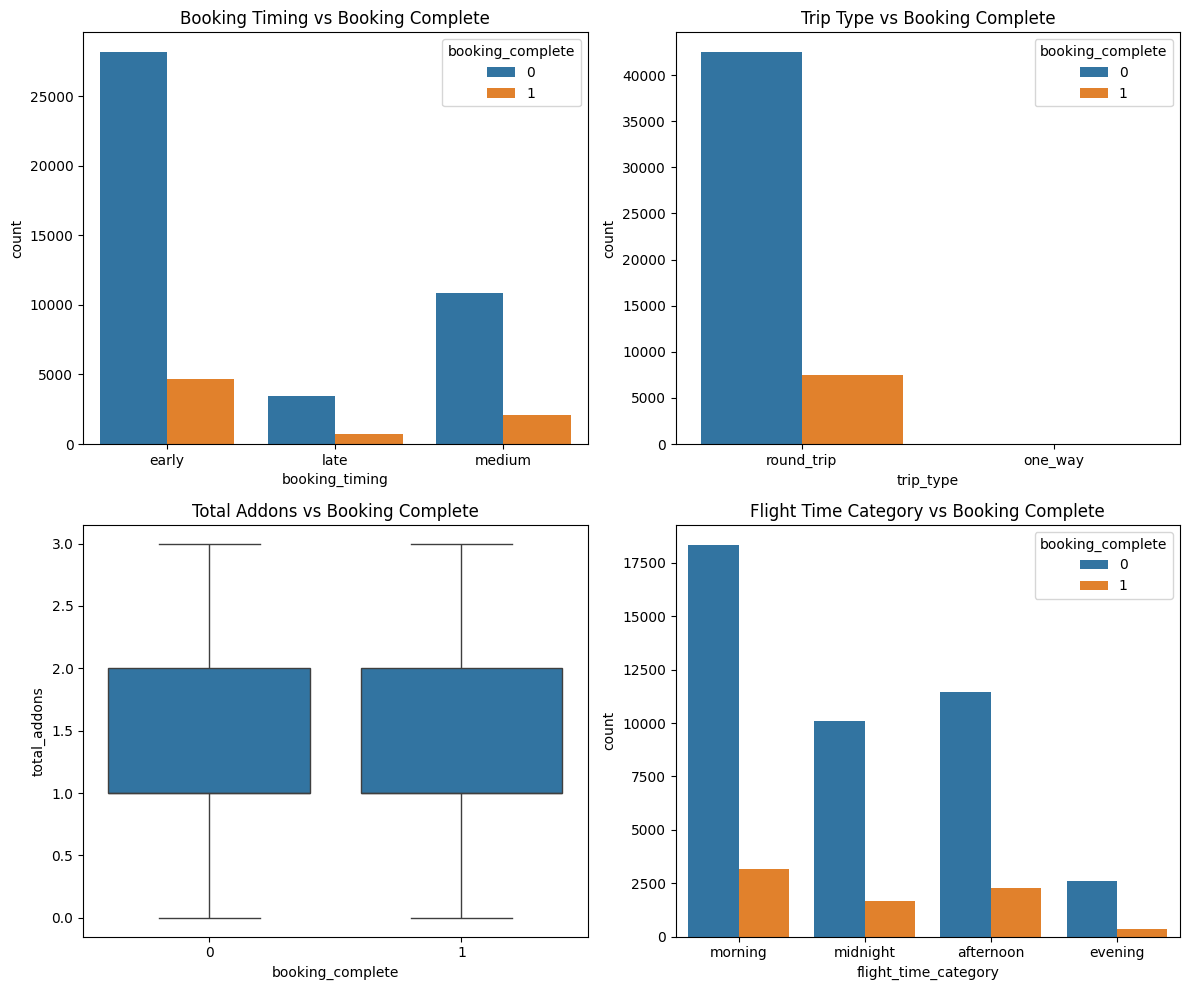

✅ Dataset baru disimpan sebagai 'customer_booking_featured.csv'


In [11]:
# =========================================================================
# 7. Feature Engineering
# =========================================================================

# Booking Timing
def categorize_lead(days):
    if days > 30:
        return 'early'
    elif days >= 7:
        return 'medium'
    else:
        return 'late'

df['booking_timing'] = df['purchase_lead'].apply(categorize_lead)

# Trip Type
df['trip_type'] = df['length_of_stay'].apply(lambda x: 'one_way' if x == 0 else 'round_trip')

# Total Add-ons
df['total_addons'] = df[['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']].sum(axis=1)

# Flight Time Category
def flight_time_category(hour):
    if 5 <= hour <= 11:
        return 'morning'
    elif 12 <= hour <= 17:
        return 'afternoon'
    elif 18 <= hour <= 23:
        return 'evening'
    else:
        return 'midnight'

df['flight_time_category'] = df['flight_hour'].apply(flight_time_category)

# Flag Long Flight
df['is_long_flight'] = (df['flight_duration'] > df['flight_duration'].median()).astype(int)

# Interaction Feature
df['lead_x_duration'] = df['purchase_lead'] * df['flight_duration']

# =========================================================================
# 8. Analisis Distribusi Fitur Baru
# =========================================================================
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

sns.countplot(data=df, x='booking_timing', hue='booking_complete', ax=axes[0,0])
axes[0,0].set_title("Booking Timing vs Booking Complete")

sns.countplot(data=df, x='trip_type', hue='booking_complete', ax=axes[0,1])
axes[0,1].set_title("Trip Type vs Booking Complete")

sns.boxplot(data=df, x='booking_complete', y='total_addons', ax=axes[1,0])
axes[1,0].set_title("Total Addons vs Booking Complete")

sns.countplot(data=df, x='flight_time_category', hue='booking_complete', ax=axes[1,1])
axes[1,1].set_title("Flight Time Category vs Booking Complete")

plt.tight_layout()
plt.show()

# =========================================================================
# 9. Simpan dataset hasil feature engineering
# =========================================================================
df.to_csv("customer_booking_featured.csv", index=False)
print("✅ Dataset baru disimpan sebagai 'customer_booking_featured.csv'")

# MODELING

In [20]:
df.select_dtypes(include='object').columns


Index(['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin',
       'booking_timing', 'flight_time_category'],
      dtype='object')

In [21]:
from sklearn.preprocessing import LabelEncoder

# Buat salinan agar aman
df_encoded = df.copy()

# Tentukan kolom kategorikal
cat_cols = ['sales_channel', 'trip_type', 'flight_day', 'route', 'booking_origin',
       'booking_timing', 'flight_time_category'] 

# Inisialisasi encoder
le = LabelEncoder()

# Encoding tiap kolom kategori
for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col])

# Pisahkan fitur dan label
X = df_encoded.drop('booking_complete', axis=1)
y = df_encoded['booking_complete']

print("Encoding selesai ✅")
print(X.head())


Encoding selesai ✅
   num_passengers  sales_channel  trip_type  purchase_lead  length_of_stay  \
0               2              0          1            262              19   
1               1              0          1            112              20   
2               2              0          1            243              22   
3               1              0          1             96              31   
4               2              0          1             68              22   

   flight_hour  flight_day  route  booking_origin  wants_extra_baggage  \
0            7           2      0              61                    1   
1            3           2      0              61                    0   
2           17           6      0              36                    1   
3            4           2      0              61                    0   
4           15           6      0              36                    1   

   wants_preferred_seat  wants_in_flight_meals  flight_duration  \


=== Cross Validation Results ===
ROC-AUC mean: 0.7688
ROC-AUC std: 0.0030

=== Classification Report (Balanced RF) ===
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.59      0.09      0.15      1496

    accuracy                           0.85     10000
   macro avg       0.72      0.54      0.54     10000
weighted avg       0.82      0.85      0.81     10000



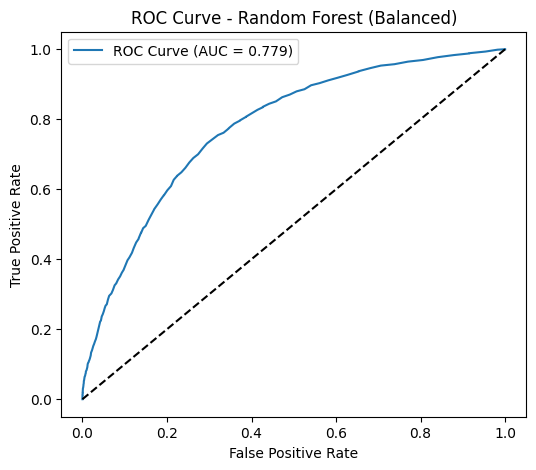

C:\Users\User\AppData\Local\Temp\ipykernel_15964\2638836023.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette='viridis')


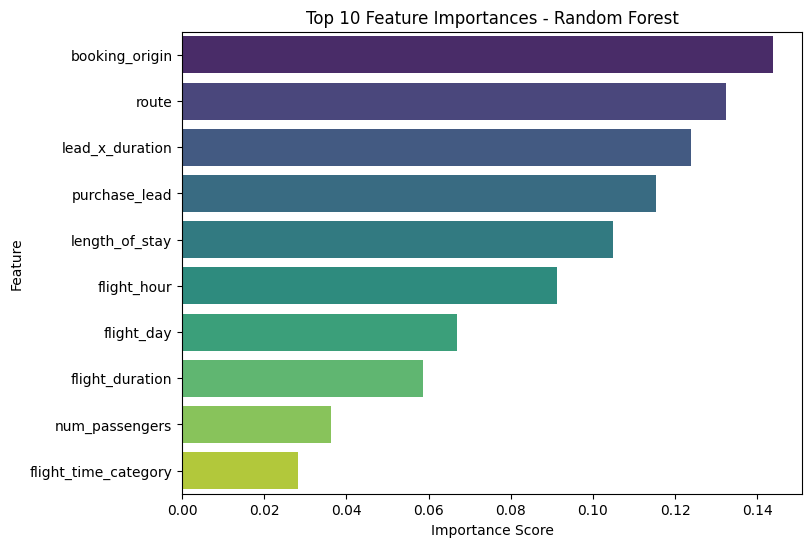

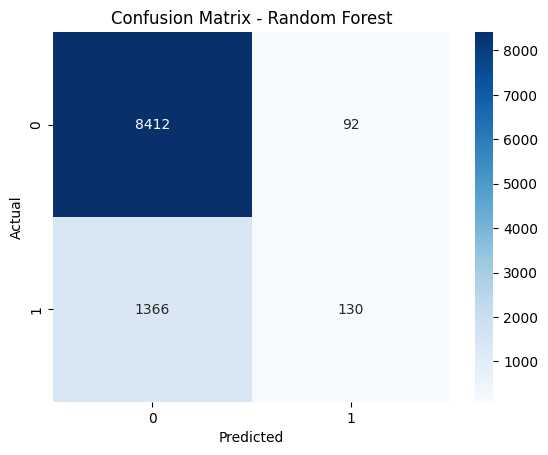

In [22]:
# ==========================================================
# 1. Import Library Tambahan
# ==========================================================
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

# ==========================================================
# 2. Model dengan class_weight='balanced' untuk tangani imbalance
# ==========================================================
from sklearn.ensemble import RandomForestClassifier

rf_balanced = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight='balanced',
    max_depth=None
)

# ==========================================================
# 3. Cross-validation (5-Fold)
# ==========================================================
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(rf_balanced, X, y, cv=cv, scoring='roc_auc')

print("=== Cross Validation Results ===")
print(f"ROC-AUC mean: {cv_scores.mean():.4f}")
print(f"ROC-AUC std: {cv_scores.std():.4f}")

# ==========================================================
# 4. Train-Test Split untuk evaluasi visual
# ==========================================================
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

rf_balanced.fit(X_train, y_train)
y_pred = rf_balanced.predict(X_test)
y_pred_proba = rf_balanced.predict_proba(X_test)[:, 1]

print("\n=== Classification Report (Balanced RF) ===")
print(classification_report(y_test, y_pred))

# ==========================================================
# 5. ROC Curve
# ==========================================================
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = roc_auc_score(y_test, y_pred_proba)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest (Balanced)")
plt.legend()
plt.show()

# ==========================================================
# 6. Feature Importance Visualization
# ==========================================================
feature_importances = pd.Series(rf_balanced.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8,6))
sns.barplot(x=feature_importances[:10], y=feature_importances.index[:10], palette='viridis')
plt.title("Top 10 Feature Importances - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# ==========================================================
# 7. Confusion Matrix
# ==========================================================
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


Ukuran data: (50000, 19)
Jumlah booking complete (1): 7478
=== Logistic Regression Report ===
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.48      0.08      0.13      1496

    accuracy                           0.85     10000
   macro avg       0.67      0.53      0.52     10000
weighted avg       0.80      0.85      0.80     10000

=== Random Forest Report ===
              precision    recall  f1-score   support

           0       0.86      0.99      0.92      8504
           1       0.56      0.10      0.17      1496

    accuracy                           0.85     10000
   macro avg       0.71      0.54      0.54     10000
weighted avg       0.82      0.85      0.81     10000



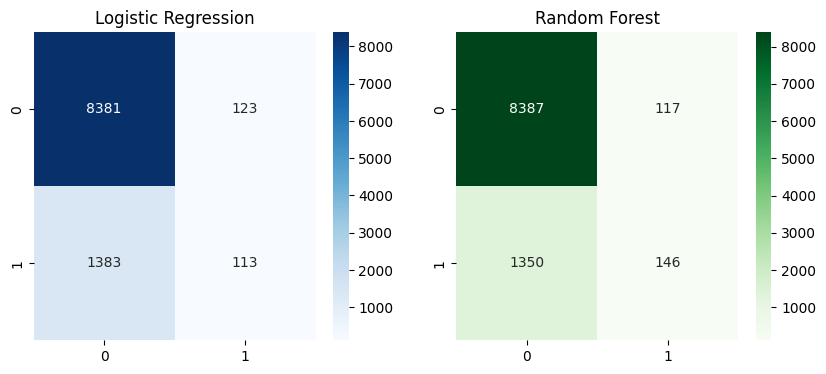

<Figure size 600x500 with 0 Axes>

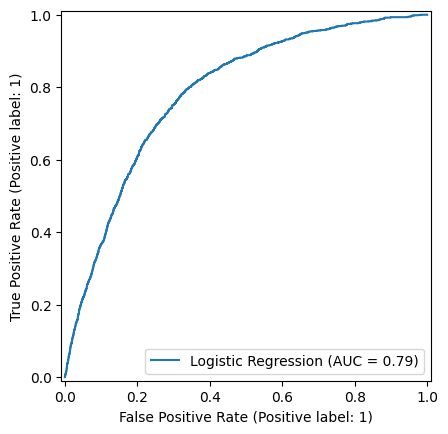

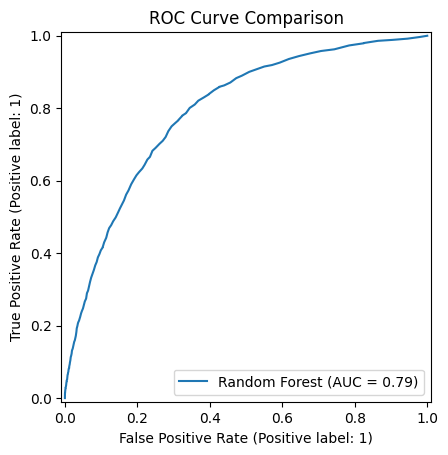

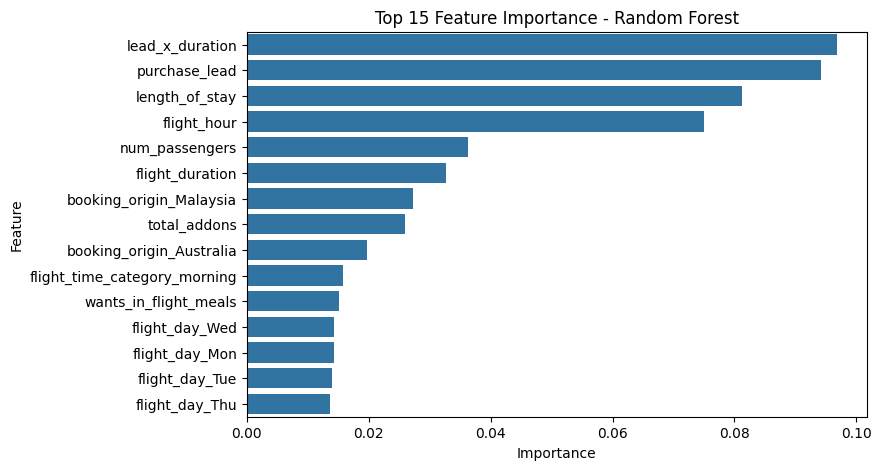

In [12]:
# =========================================================================
# 1. Import Libraries
# =========================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================================================
# 2. Load dataset hasil feature engineering
# =========================================================================
df = pd.read_csv("customer_booking_featured.csv")

print("Ukuran data:", df.shape)
print("Jumlah booking complete (1):", df['booking_complete'].sum())

# =========================================================================
# 3. Pisahkan fitur dan label
# =========================================================================
X = df.drop('booking_complete', axis=1)
y = df['booking_complete']

# Tentukan kolom kategorikal & numerik
cat_cols = X.select_dtypes(include=['object']).columns.tolist()
num_cols = X.select_dtypes(exclude=['object']).columns.tolist()

# =========================================================================
# 4. Preprocessing
# =========================================================================
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# =========================================================================
# 5. Split data train-test
# =========================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# =========================================================================
# 6. Model 1: Logistic Regression
# =========================================================================
logreg_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', LogisticRegression(max_iter=1000))
])

logreg_pipeline.fit(X_train, y_train)
y_pred_log = logreg_pipeline.predict(X_test)
y_prob_log = logreg_pipeline.predict_proba(X_test)[:, 1]

# =========================================================================
# 7. Model 2: Random Forest
# =========================================================================
rf_pipeline = Pipeline([
    ('preprocess', preprocessor),
    ('clf', RandomForestClassifier(n_estimators=200, random_state=42))
])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

# =========================================================================
# 8. Evaluasi Model
# =========================================================================
print("=== Logistic Regression Report ===")
print(classification_report(y_test, y_pred_log))

print("=== Random Forest Report ===")
print(classification_report(y_test, y_pred_rf))

# =========================================================================
# 9. Confusion Matrix
# =========================================================================
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues', ax=ax[0])
ax[0].set_title("Logistic Regression")
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens', ax=ax[1])
ax[1].set_title("Random Forest")
plt.show()

# =========================================================================
# 10. ROC Curve
# =========================================================================
plt.figure(figsize=(6,5))
RocCurveDisplay.from_predictions(y_test, y_prob_log, name="Logistic Regression")
RocCurveDisplay.from_predictions(y_test, y_prob_rf, name="Random Forest")
plt.title("ROC Curve Comparison")
plt.show()

# =========================================================================
# 11. Feature Importance (untuk Random Forest)
# =========================================================================
# Ambil nama fitur setelah OneHotEncoding
encoder = rf_pipeline.named_steps['preprocess'].named_transformers_['cat']
encoded_cat_names = encoder.get_feature_names_out(cat_cols)
all_features = np.concatenate([num_cols, encoded_cat_names])

importances = rf_pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.DataFrame({'Feature': all_features, 'Importance': importances})
feat_imp = feat_imp.sort_values(by='Importance', ascending=False).head(15)

plt.figure(figsize=(8,5))
sns.barplot(x='Importance', y='Feature', data=feat_imp)
plt.title("Top 15 Feature Importance - Random Forest")
plt.show()


# EDA Additional

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for all plots
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('viridis')

# Load the dataset
df = pd.read_csv("customer_booking.csv", encoding="ISO-8859-1")

print(f"Dataset dimensions: {df.shape[0]} rows and {df.shape[1]} columns")

Dataset dimensions: 50000 rows and 14 columns


In [2]:
# Display first few rows
display(df.head())

# Check data types and missing values
print("\nData Information:")
df.info()

# Basic statistics
print("\nDescriptive Statistics:")
display(df.describe().T)

# Check missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check unique values for categorical columns
print("\nUnique values in categorical columns:")
for col in df.select_dtypes(include=['object']).columns:
    print(f"{col}: {df[col].nunique()} unique values")
    if df[col].nunique() < 10:
        print(df[col].value_counts())
    print()

,num_passengers,sales_channel,trip_type,purchase_lead,length_of_stay,flight_hour,flight_day,route,booking_origin,wants_extra_baggage,wants_preferred_seat,wants_in_flight_meals,flight_duration,booking_complete
0,2,Internet,RoundTrip,262,19,7,Sat,AKLDEL,New Zealand,1,0,0,5.52,0
1,1,Internet,RoundTrip,112,20,3,Sat,AKLDEL,New Zealand,0,0,0,5.52,0
2,2,Internet,RoundTrip,243,22,17,Wed,AKLDEL,India,1,1,0,5.52,0
3,1,Internet,RoundTrip,96,31,4,Sat,AKLDEL,New Zealand,0,0,1,5.52,0
4,2,Internet,RoundTrip,68,22,15,Wed,AKLDEL,India,1,0,1,5.52,0



Data Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)


,count,mean,std,min,25%,50%,75%,max
num_passengers,50000.0,1.591240,1.020165,1.00,1.00,1.00,2.00,9.0
purchase_lead,50000.0,84.940480,90.451378,0.00,21.00,51.00,115.00,867.0
length_of_stay,50000.0,23.044560,33.887670,0.00,5.00,17.00,28.00,778.0
flight_hour,50000.0,9.066340,5.412660,0.00,5.00,9.00,13.00,23.0
wants_extra_baggage,50000.0,0.668780,0.470657,0.00,0.00,1.00,1.00,1.0
wants_preferred_seat,50000.0,0.296960,0.456923,0.00,0.00,0.00,1.00,1.0
wants_in_flight_meals,50000.0,0.427140,0.494668,0.00,0.00,0.00,1.00,1.0
flight_duration,50000.0,7.277561,1.496863,4.67,5.62,7.57,8.83,9.5
booking_complete,50000.0,0.149560,0.356643,0.00,0.00,0.00,0.00,1.0



Missing values per column:
num_passengers           0
sales_channel            0
trip_type                0
purchase_lead            0
length_of_stay           0
flight_hour              0
flight_day               0
route                    0
booking_origin           0
wants_extra_baggage      0
wants_preferred_seat     0
wants_in_flight_meals    0
flight_duration          0
booking_complete         0
dtype: int64

Unique values in categorical columns:
sales_channel: 2 unique values
sales_channel
Internet    44382
Mobile       5618
Name: count, dtype: int64

trip_type: 3 unique values
trip_type
RoundTrip     49497
OneWay          387
CircleTrip      116
Name: count, dtype: int64

flight_day: 7 unique values
flight_day
Mon    8102
Wed    7674
Tue    7673
Thu    7424
Fri    6761
Sun    6554
Sat    5812
Name: count, dtype: int64

route: 799 unique values

booking_origin: 104 unique values



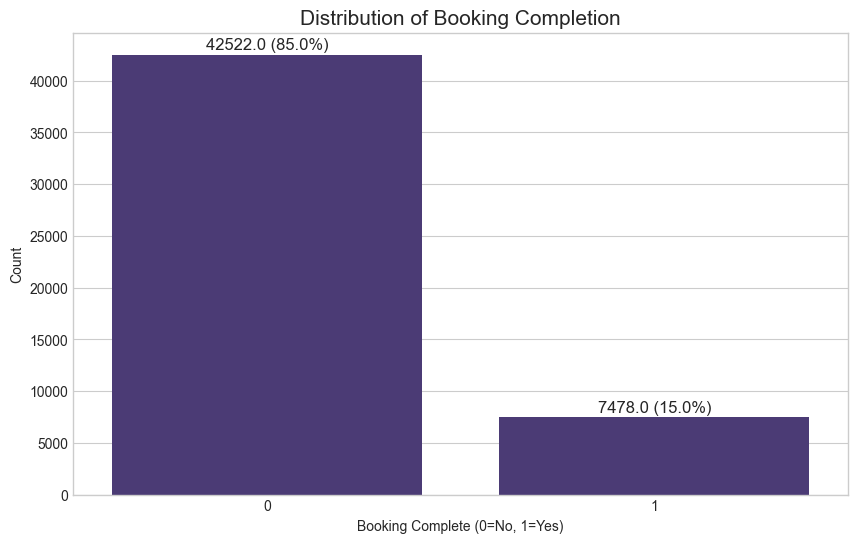

In [3]:
# Distribution of target variable
plt.figure(figsize=(10, 6))
ax = sns.countplot(x='booking_complete', data=df)
plt.title('Distribution of Booking Completion', fontsize=15)
plt.xlabel('Booking Complete (0=No, 1=Yes)')
plt.ylabel('Count')

# Add percentages on top of bars
total = len(df)
for p in ax.patches:
    height = p.get_height()
    ax.annotate(f'{height} ({100*height/total:.1f}%)', 
                (p.get_x() + p.get_width()/2, height + 0.01*total),
                ha='center', fontsize=12)
plt.show()

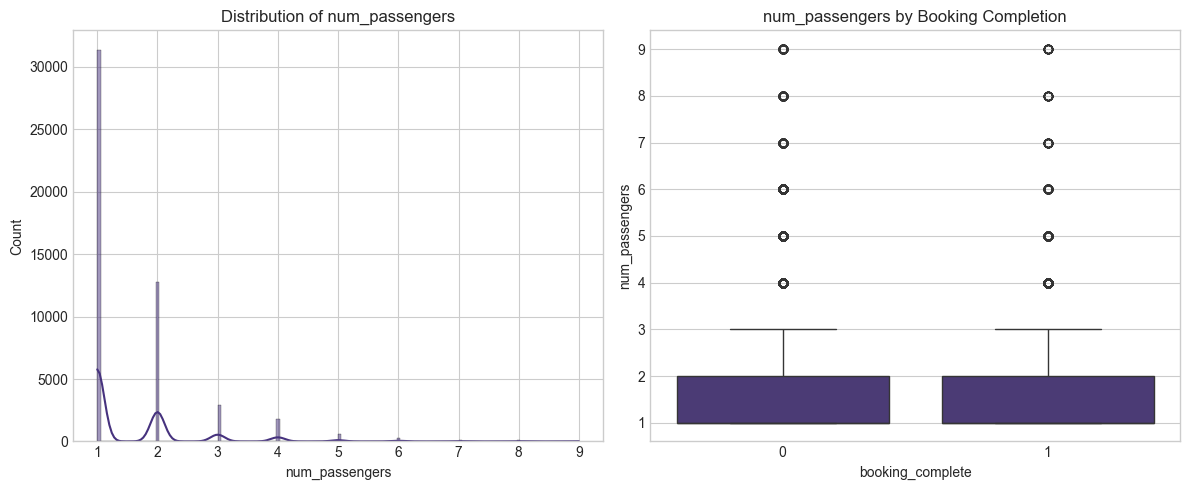

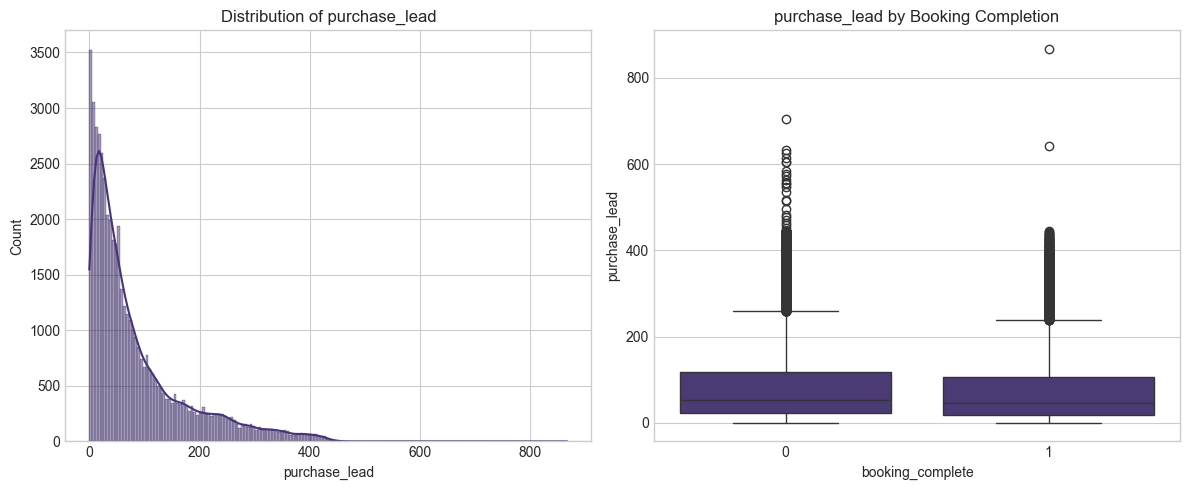

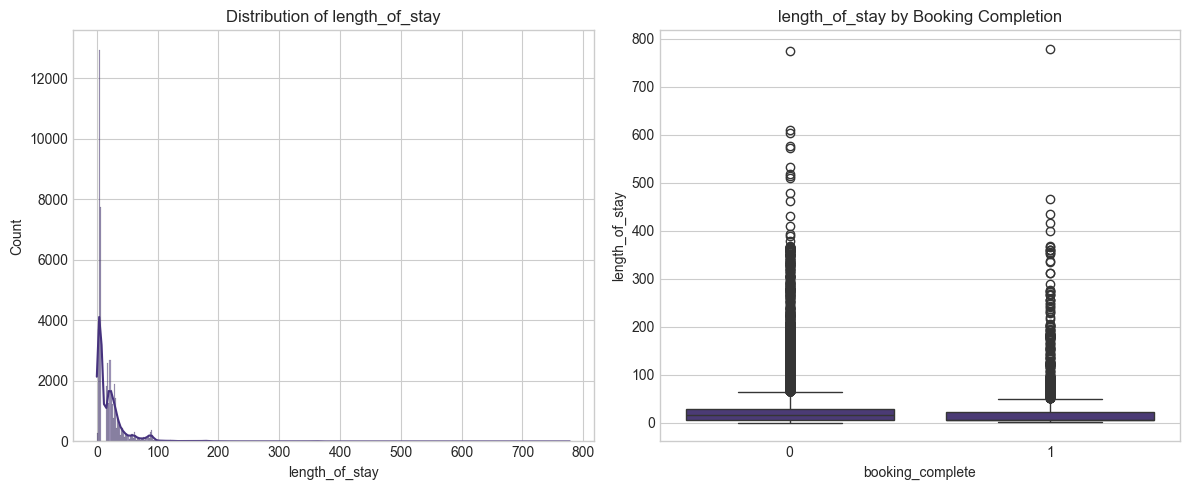

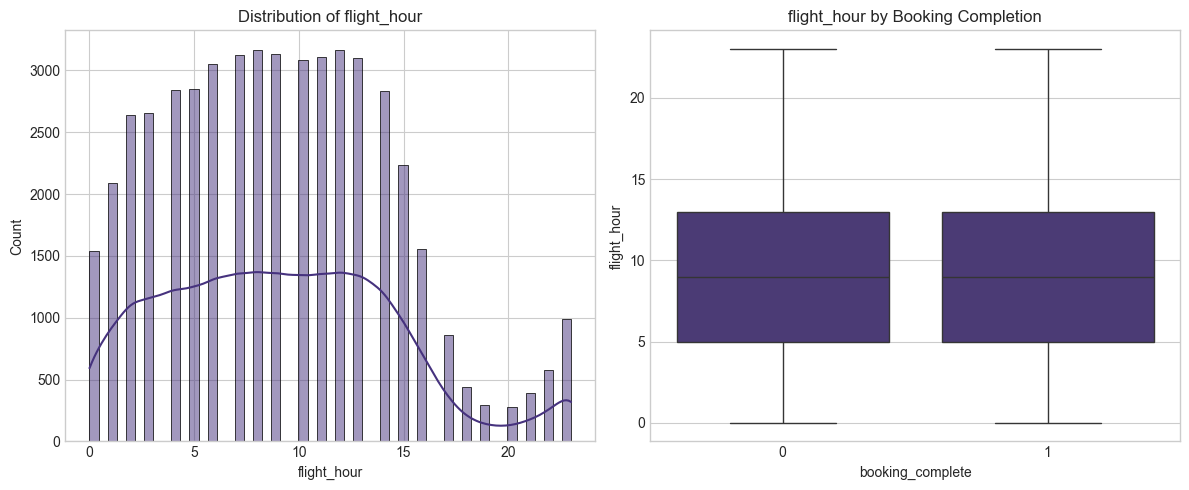

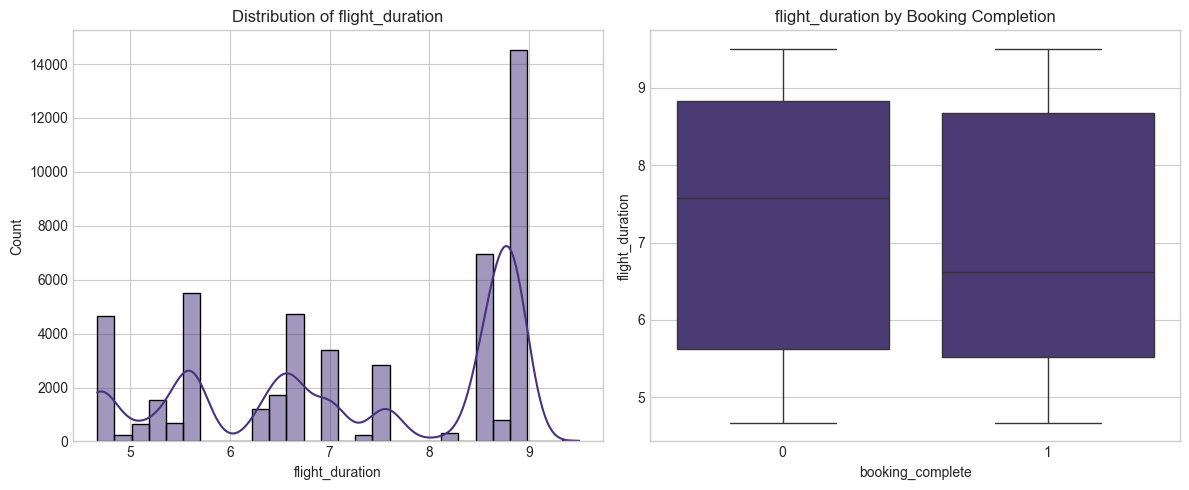

In [4]:
# Function to plot numerical features
def plot_numerical(col_name):
    plt.figure(figsize=(12, 5))
    
    # Distribution
    plt.subplot(1, 2, 1)
    sns.histplot(df[col_name], kde=True)
    plt.title(f'Distribution of {col_name}')
    
    # Relationship with target
    plt.subplot(1, 2, 2)
    sns.boxplot(x='booking_complete', y=col_name, data=df)
    plt.title(f'{col_name} by Booking Completion')
    plt.tight_layout()
    plt.show()

# Analyze numerical variables
for col in ['num_passengers', 'purchase_lead', 'length_of_stay', 
            'flight_hour', 'flight_duration']:
    plot_numerical(col)

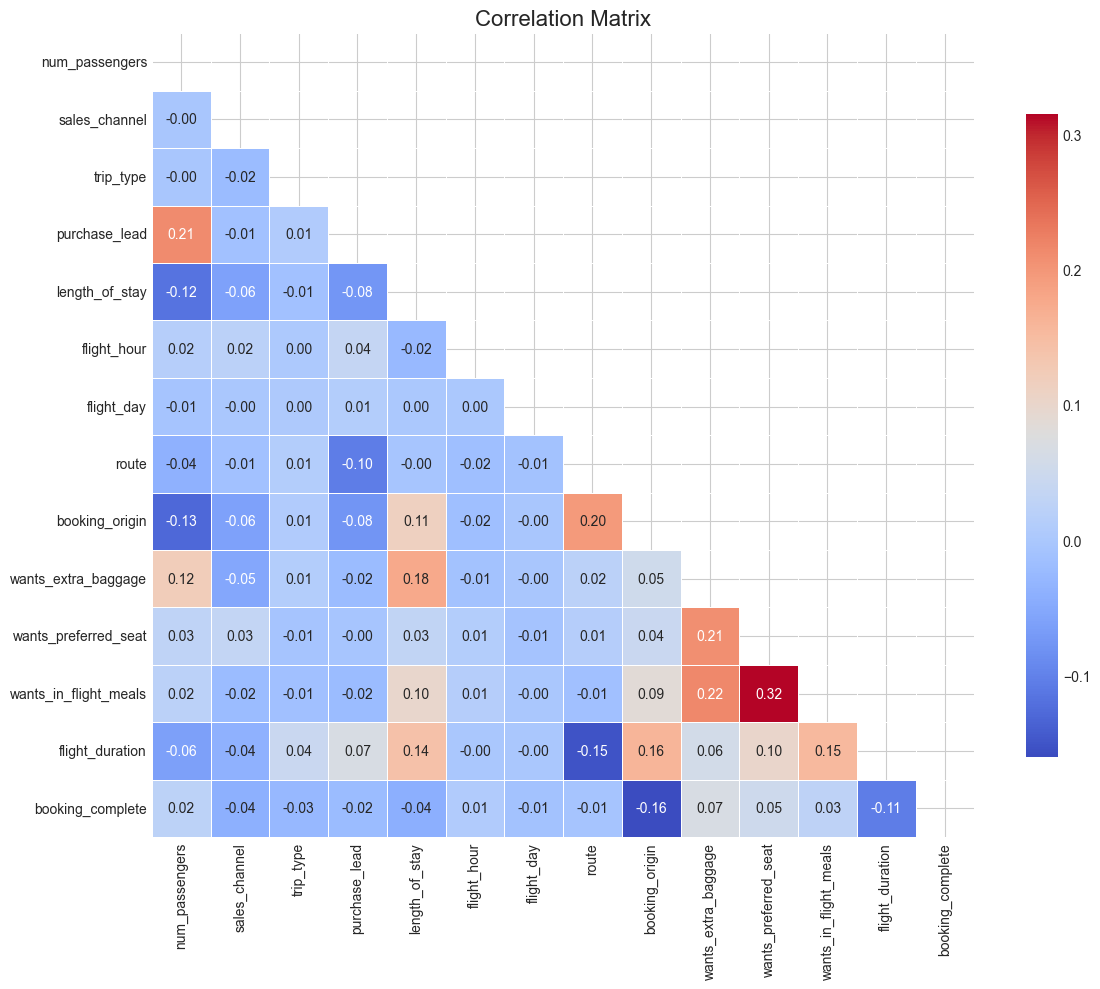

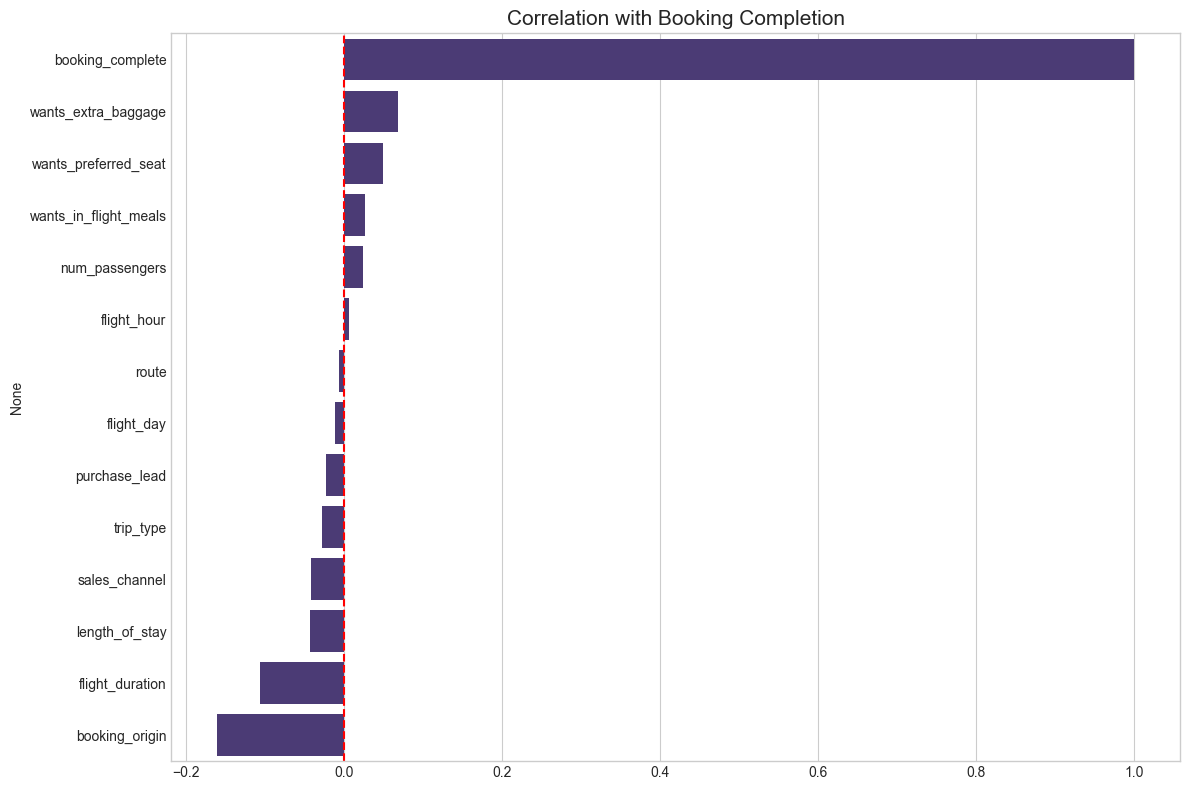

In [5]:
# Convert categorical variables
df_corr = df.copy()
for col in df_corr.select_dtypes(include=['object']).columns:
    df_corr[col] = pd.factorize(df_corr[col])[0]

# Correlation matrix
plt.figure(figsize=(12, 10))
corr = df_corr.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap='coolwarm', 
            linewidths=0.5, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix', fontsize=16)
plt.tight_layout()
plt.show()

# Correlation with target variable
plt.figure(figsize=(12, 8))
target_corr = corr['booking_complete'].sort_values(ascending=False)
sns.barplot(x=target_corr.values, y=target_corr.index)
plt.title('Correlation with Booking Completion', fontsize=15)
plt.axvline(x=0, color='red', linestyle='--')
plt.tight_layout()
plt.show()

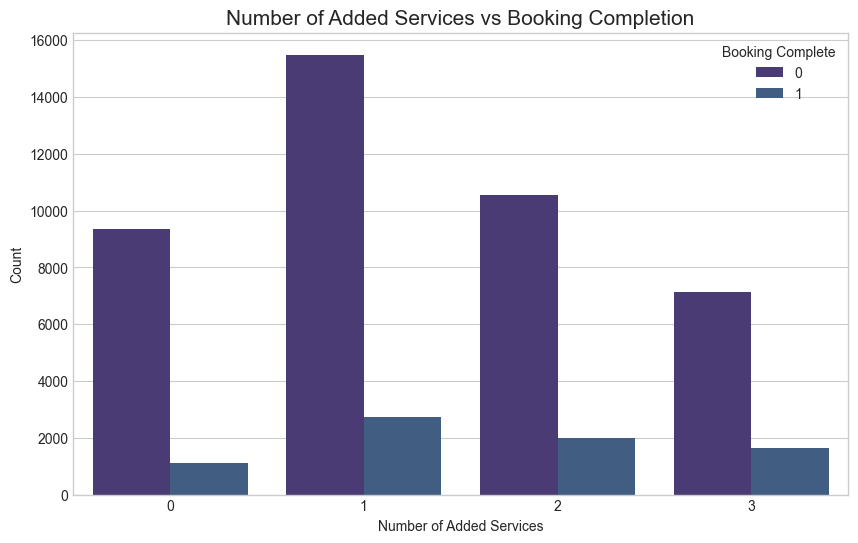

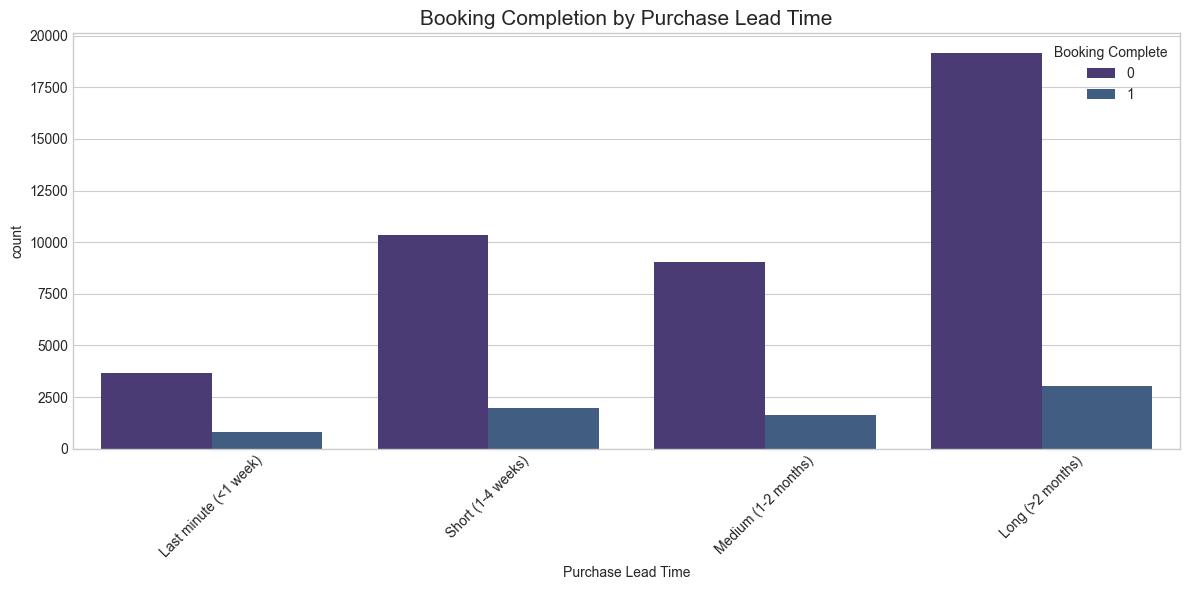

In [6]:
# Analyze customer preferences together
plt.figure(figsize=(10, 6))
preferences = ['wants_extra_baggage', 'wants_preferred_seat', 'wants_in_flight_meals']
df['total_preferences'] = df[preferences].sum(axis=1)

sns.countplot(x='total_preferences', hue='booking_complete', data=df)
plt.title('Number of Added Services vs Booking Completion', fontsize=15)
plt.xlabel('Number of Added Services')
plt.ylabel('Count')
plt.legend(title='Booking Complete')
plt.show()

# Purchase lead time analysis
plt.figure(figsize=(12, 6))
bins = [0, 7, 30, 60, df['purchase_lead'].max()]
labels = ['Last minute (<1 week)', 'Short (1-4 weeks)', 'Medium (1-2 months)', 'Long (>2 months)']
df['lead_time_category'] = pd.cut(df['purchase_lead'], bins=bins, labels=labels)

sns.countplot(x='lead_time_category', hue='booking_complete', data=df)
plt.title('Booking Completion by Purchase Lead Time', fontsize=15)
plt.xlabel('Purchase Lead Time')
plt.xticks(rotation=45)
plt.legend(title='Booking Complete')
plt.tight_layout()
plt.show()

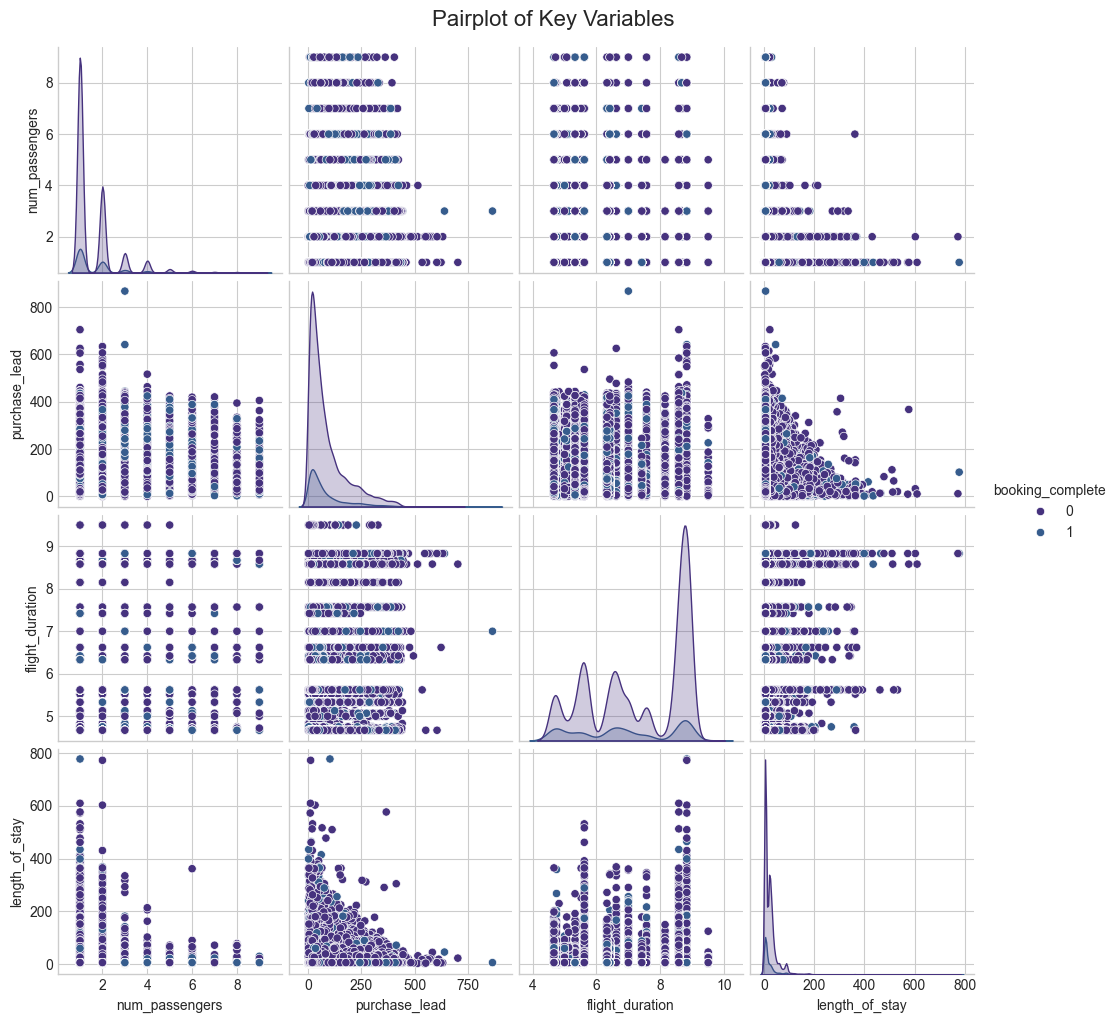

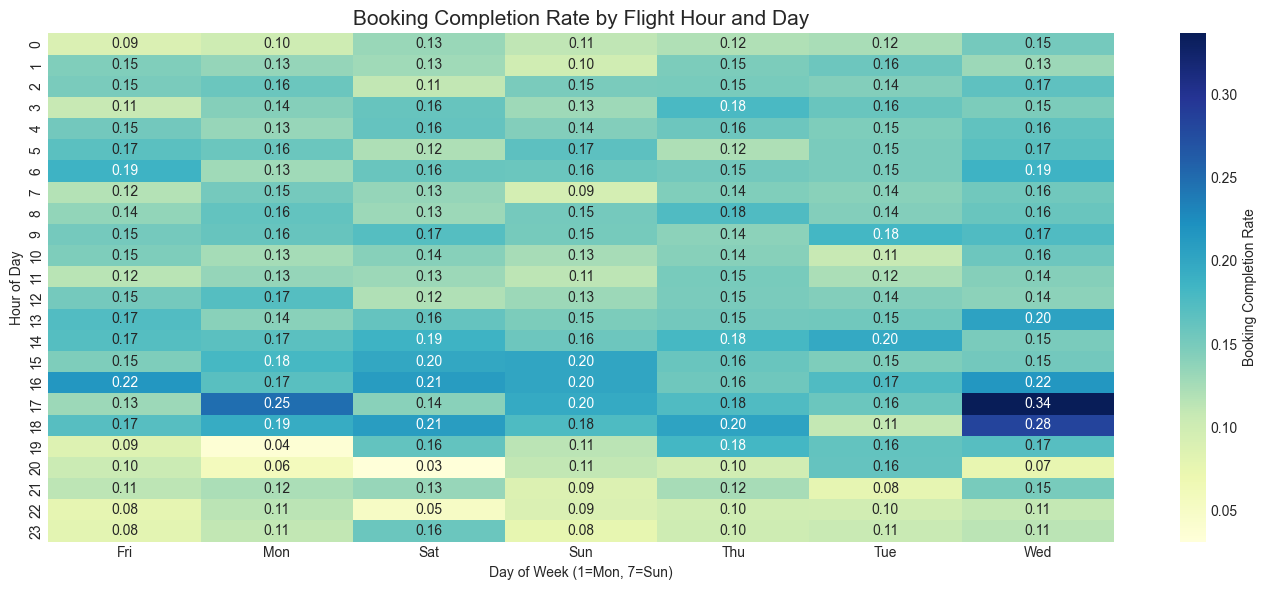

In [7]:
# Create a pairplot for key variables
key_vars = ['num_passengers', 'purchase_lead', 'flight_duration', 'length_of_stay', 'booking_complete']
sns.pairplot(df[key_vars], hue='booking_complete', diag_kind='kde')
plt.suptitle('Pairplot of Key Variables', y=1.02, fontsize=16)
plt.show()

# Flight hour and day analysis
plt.figure(figsize=(14, 6))
pivot_data = df.pivot_table(values='booking_complete', index='flight_hour', 
                            columns='flight_day', aggfunc='mean')
                            
sns.heatmap(pivot_data, cmap='YlGnBu', annot=True, fmt='.2f', cbar_kws={'label': 'Booking Completion Rate'})
plt.title('Booking Completion Rate by Flight Hour and Day', fontsize=15)
plt.xlabel('Day of Week (1=Mon, 7=Sun)')
plt.ylabel('Hour of Day')
plt.tight_layout()
plt.show()